## Unit 8. Neural Networks and Deep Learning

Fashion classification using images

### 8.1 Fashion Classification

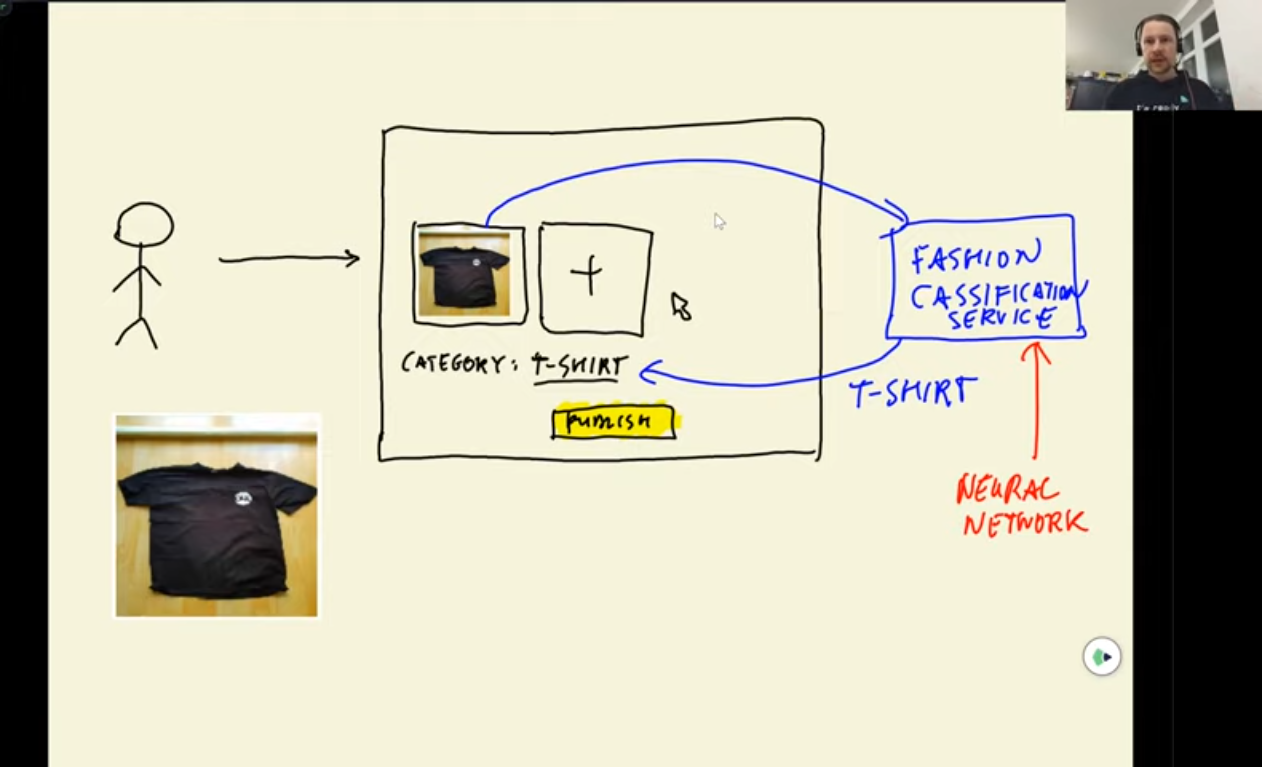

Theory:
https://cs231n.github.io/

### 8.2 TensorFlow and Keras

- Installing TensorFlow
- Loading images

In [5]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
import tensorflow as tf
from tensorflow import keras

In [7]:
from tensorflow.keras.preprocessing.image import load_img

In [8]:
path = "./clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
fullname = f'{path}/{name}'
fullname

'./clothing-dataset-small/train/t-shirt/5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'

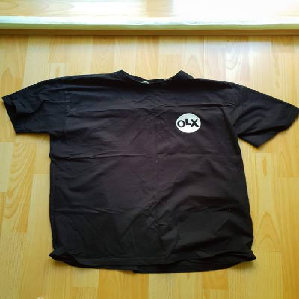

In [9]:
img = load_img(fullname, target_size=(299, 299))
img

Why to specify the size
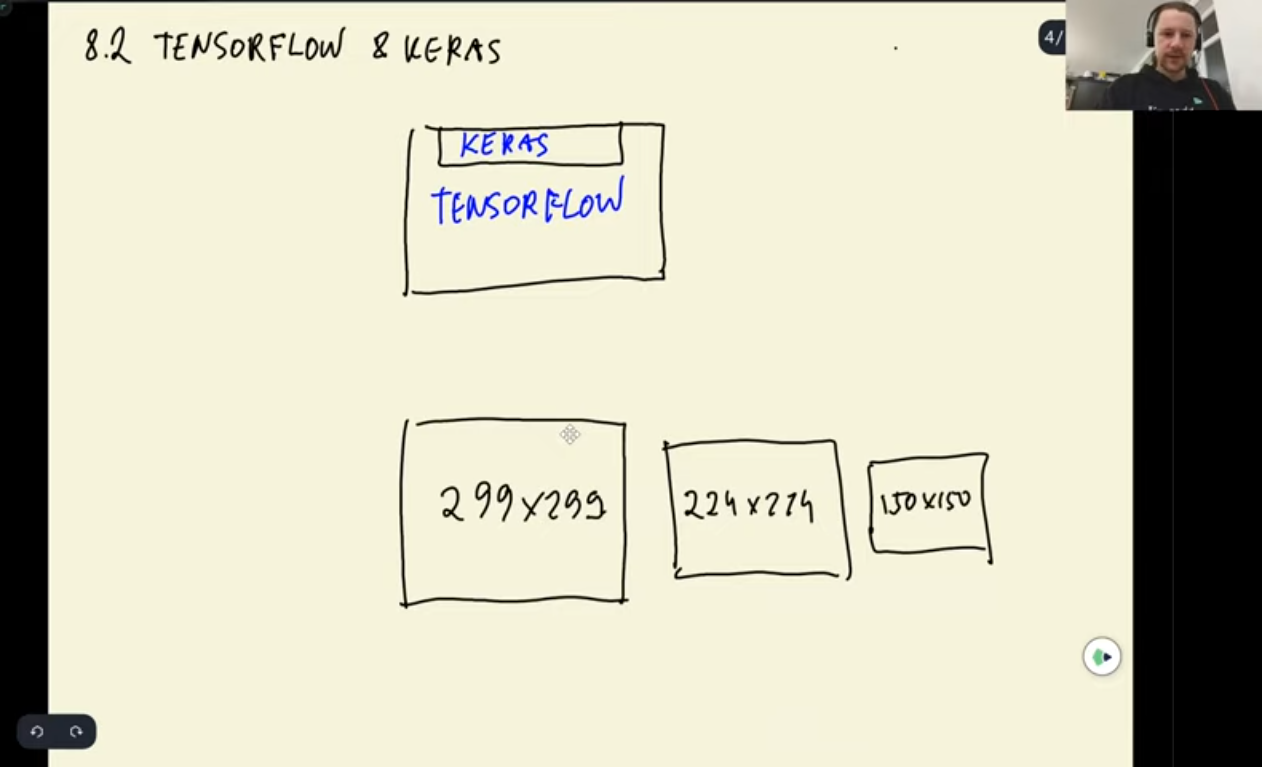

In [10]:
# Translating the image into a numpy array
x = np.array(img)
x.shape

(299, 299, 3)

In [11]:
x

array([[[179, 171,  99],
        [179, 171,  99],
        [181, 173, 101],
        ...,
        [251, 253, 248],
        [251, 253, 248],
        [251, 254, 247]],

       [[188, 179, 112],
        [187, 178, 111],
        [186, 177, 108],
        ...,
        [251, 252, 247],
        [251, 252, 247],
        [251, 252, 246]],

       [[199, 189, 127],
        [200, 190, 128],
        [200, 191, 126],
        ...,
        [250, 251, 245],
        [250, 251, 245],
        [250, 251, 245]],

       ...,

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [183, 135,  25],
        [181, 133,  22],
        [183, 135,  24]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [182, 134,  23],
        [180, 132,  21],
        [182, 134,  23]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [181, 133,  22],
        [179, 131,  20],
        [182, 134,  23]]

### 8.3 Pre-trained convolutional neural networks

Imagenet datasets: image-net.org

Pre-trained models: keras.io/api/applications

In [12]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [13]:
model = Xception(weights='imagenet', input_shape=(299,299,3))

E0000 00:00:1764347216.845167    8981 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1764347216.850862    8981 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [14]:
# Putting an image into an array of images because the model expects a batch of images
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [15]:
# The image should be preprocessed to make sense
X = preprocess_input(X)

In [16]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


array([[3.23712302e-04, 1.57383896e-04, 2.13493287e-04, 1.52370572e-04,
        2.47626333e-04, 3.05035966e-04, 3.20592400e-04, 1.47499362e-04,
        2.03621923e-04, 1.49272484e-04, 1.95663175e-04, 2.10137499e-04,
        7.59265313e-05, 1.13972274e-04, 1.62683617e-04, 2.04638694e-04,
        1.97416230e-04, 1.44288933e-04, 1.40217555e-04, 1.73686043e-04,
        7.46690610e-04, 2.56966887e-04, 2.66808958e-04, 2.96514481e-04,
        3.73602641e-04, 2.77404353e-04, 2.16570945e-04, 2.27270240e-04,
        3.80813086e-04, 1.72166023e-04, 3.05401161e-04, 1.96431400e-04,
        3.92115151e-04, 4.78071859e-04, 2.91751436e-04, 3.25693487e-04,
        1.47395302e-04, 1.62362150e-04, 2.12710656e-04, 1.34028320e-04,
        2.40070614e-04, 6.75212184e-04, 2.54943705e-04, 1.44478807e-04,
        4.12821537e-04, 2.04408745e-04, 3.02958302e-04, 1.49339685e-04,
        1.99653805e-04, 2.27005963e-04, 2.93729419e-04, 2.27444776e-04,
        6.37644727e-04, 7.82616087e-04, 2.49557430e-04, 4.052708

In [17]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [18]:
# Deoding predictions for human-readable format
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.6819629)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03814003)),
  ('n04370456', 'sweatshirt', np.float32(0.0343248)),
  ('n03710637', 'maillot', np.float32(0.011354244)),
  ('n04525038', 'velvet', np.float32(0.0018453615))]]

### 8.4 Convolutional neural networks

- Types of layers: convolutional and dense
- Convolutional layers and filters
- Dense layers

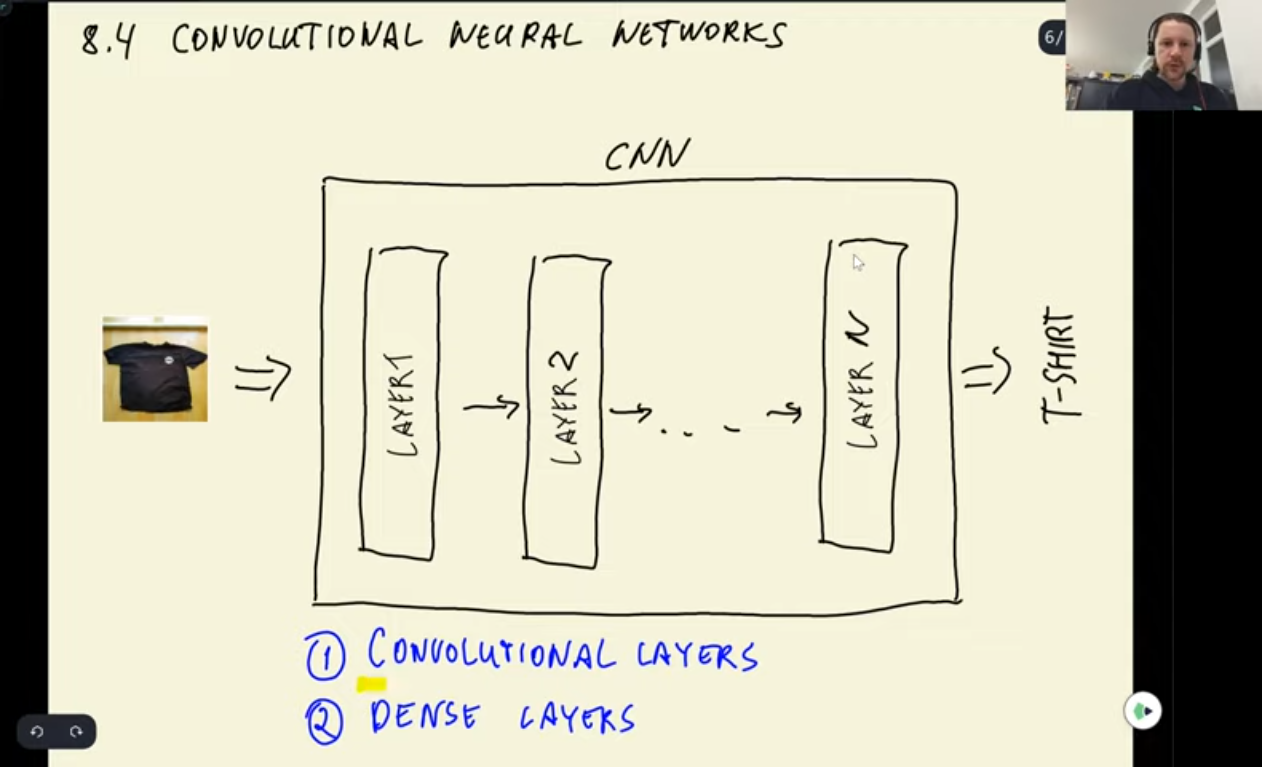

Filters - small images that contain simple shapes. We calculate similarity of the filter with particular part of the image
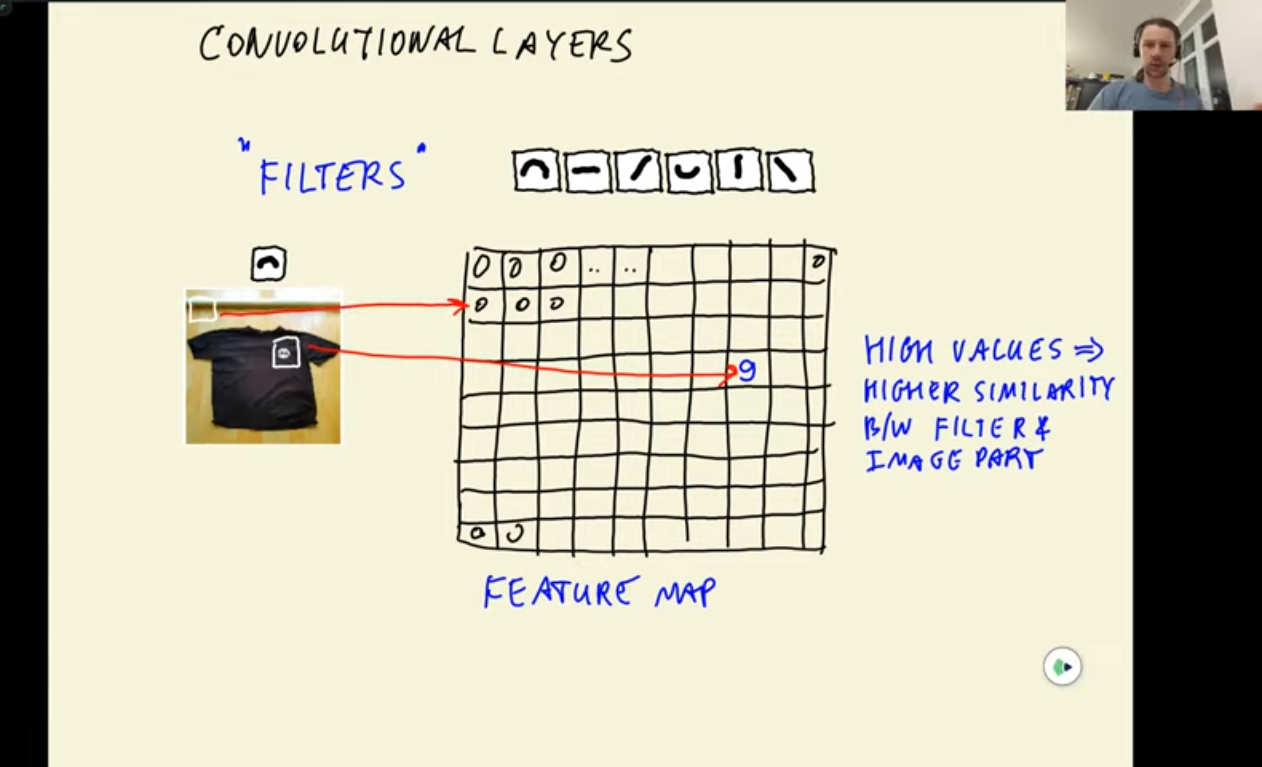

One feature map per filter
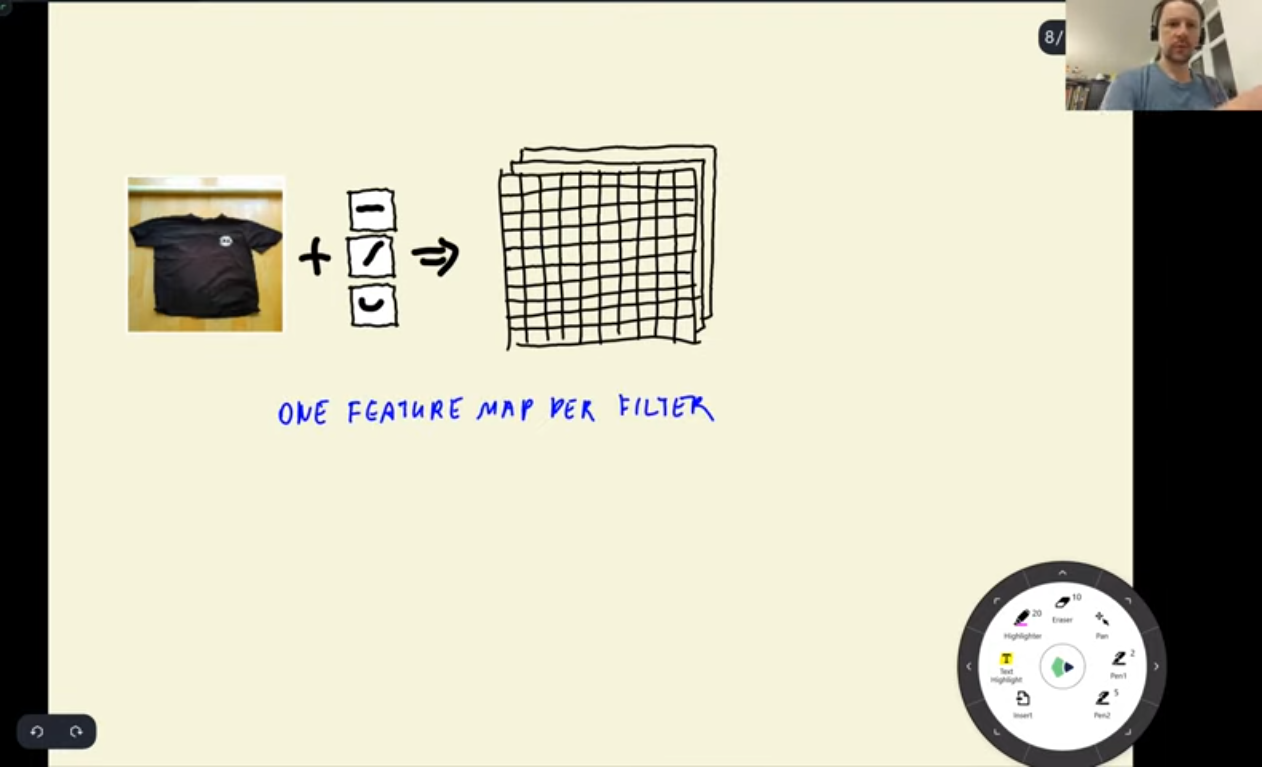

Each new level introduces more complex filters that often combine simpler filters
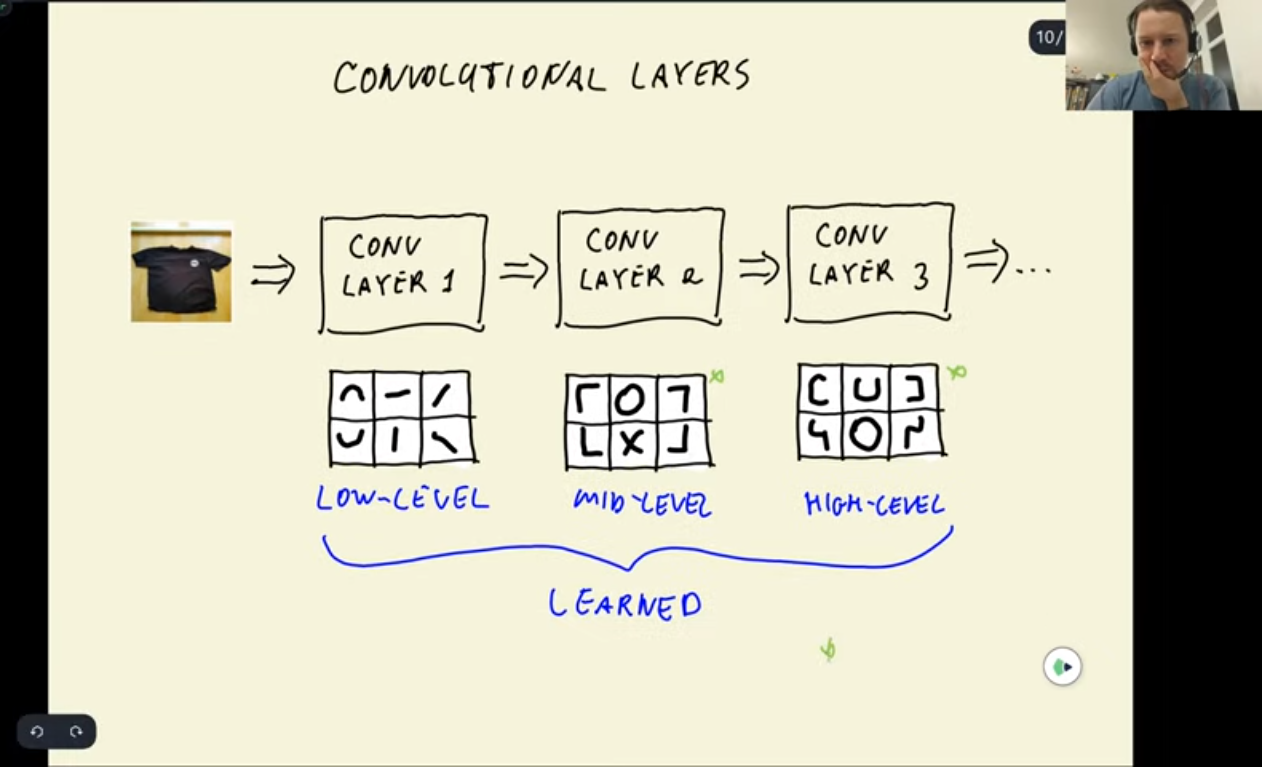

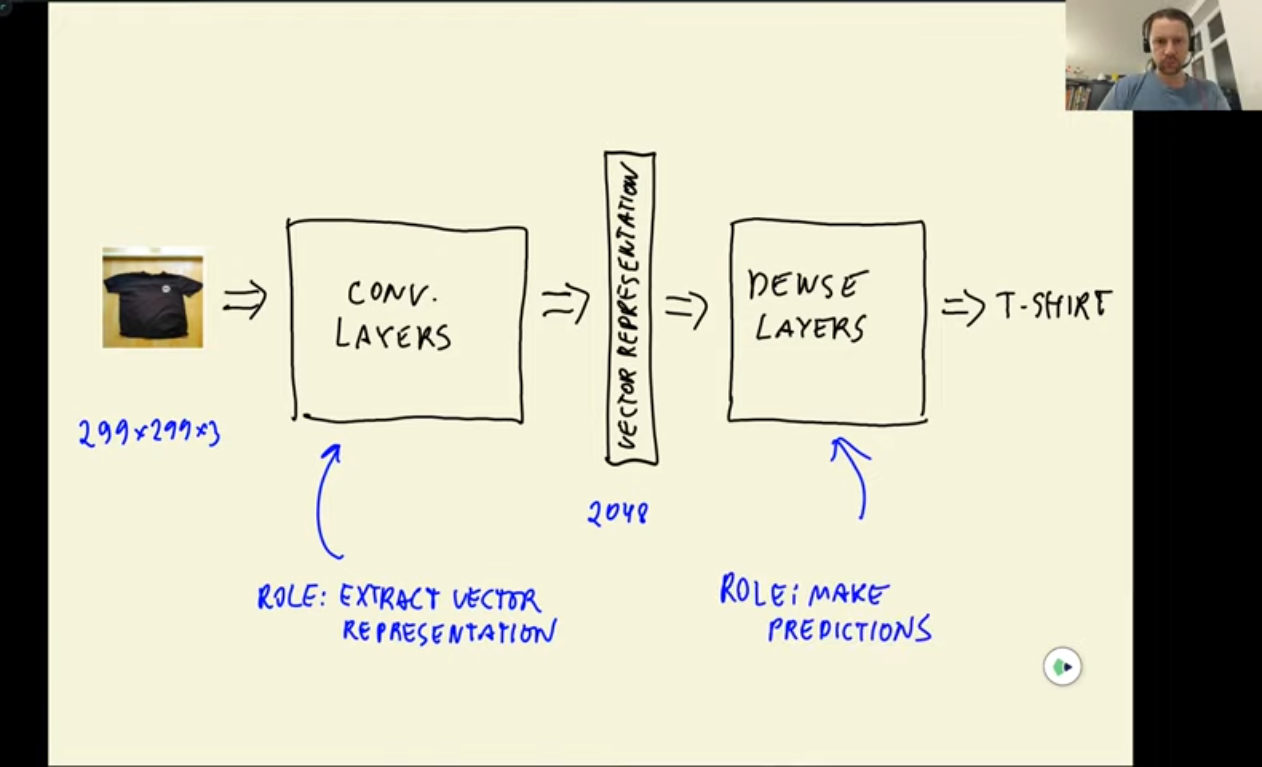

Dense layer is just matrix multiplication
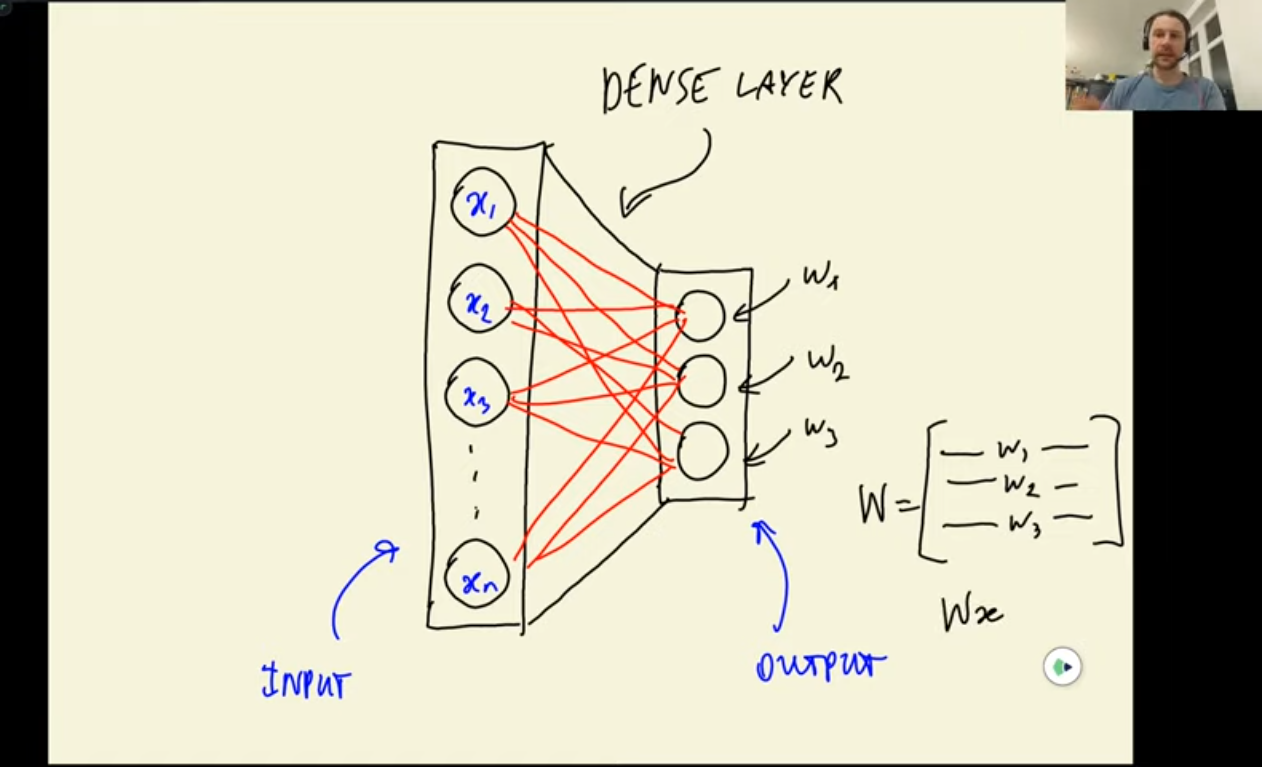

### 8.5 Transfer learning

Model needs to see a lot of images to come up with filters that make sense.

We want to keep the convolutional layers and retrain the model to get new dense layers
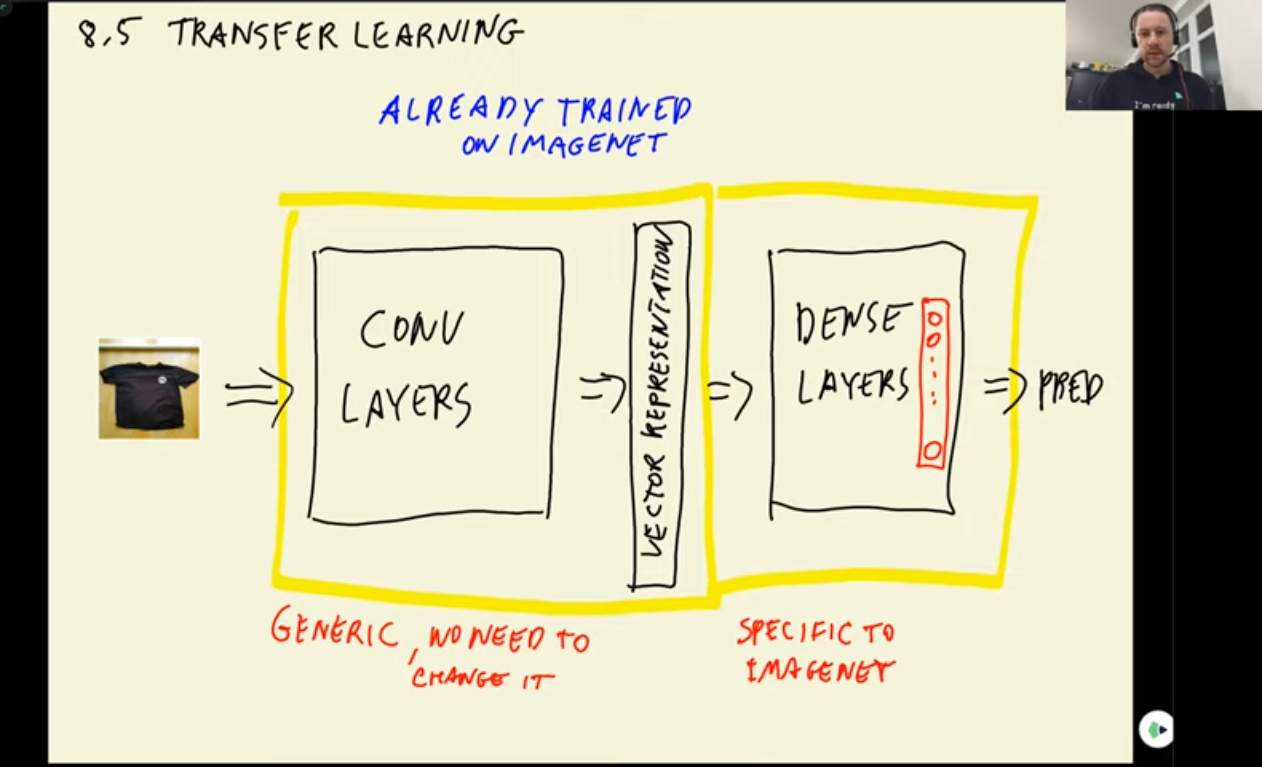

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [21]:
# Using smaller images to make training faster
train_ds = train_gen.flow_from_directory('./clothing-dataset-small/train',
                                         target_size=(150, 150),
                                         batch_size=32)

Found 3068 images belonging to 10 classes.


In [22]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [23]:
# Looking what dataset generates
X, y = next(train_ds)

In [24]:
X

array([[[[ 0.24705887,  0.17647064,  0.10588241],
         [ 0.32549024,  0.254902  ,  0.18431377],
         [ 0.3803922 ,  0.30980396,  0.23921573],
         ...,
         [ 0.5529412 ,  0.48235297,  0.41176474],
         [ 0.56078434,  0.4901961 ,  0.41960788],
         [ 0.5686275 ,  0.49803925,  0.427451  ]],

        [[ 0.45098042,  0.3803922 ,  0.30980396],
         [ 0.48235297,  0.41176474,  0.3411765 ],
         [ 0.5058824 ,  0.43529415,  0.36470592],
         ...,
         [ 0.5686275 ,  0.49803925,  0.427451  ],
         [ 0.5764706 ,  0.5058824 ,  0.43529415],
         [ 0.58431375,  0.5137255 ,  0.4431373 ]],

        [[ 0.48235297,  0.41176474,  0.3411765 ],
         [ 0.49803925,  0.427451  ,  0.35686278],
         [ 0.49803925,  0.427451  ,  0.35686278],
         ...,
         [ 0.5764706 ,  0.5058824 ,  0.43529415],
         [ 0.5764706 ,  0.5058824 ,  0.43529415],
         [ 0.5764706 ,  0.5058824 ,  0.43529415]],

        ...,

        [[ 0.26274514,  0.19215691,  0

In [25]:
X.shape

(32, 150, 150, 3)

In [26]:
# Target variable - one-hot encoding is used for labels
y[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [27]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = train_gen.flow_from_directory('./clothing-dataset-small/validation',
                                       target_size=(150, 150),
                                       batch_size=32, 
                                       shuffle=False)

Found 341 images belonging to 10 classes.


In [28]:
# Keeping convolutional layers from Xception model
base_model = Xception(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3))

base_model.trainable=False

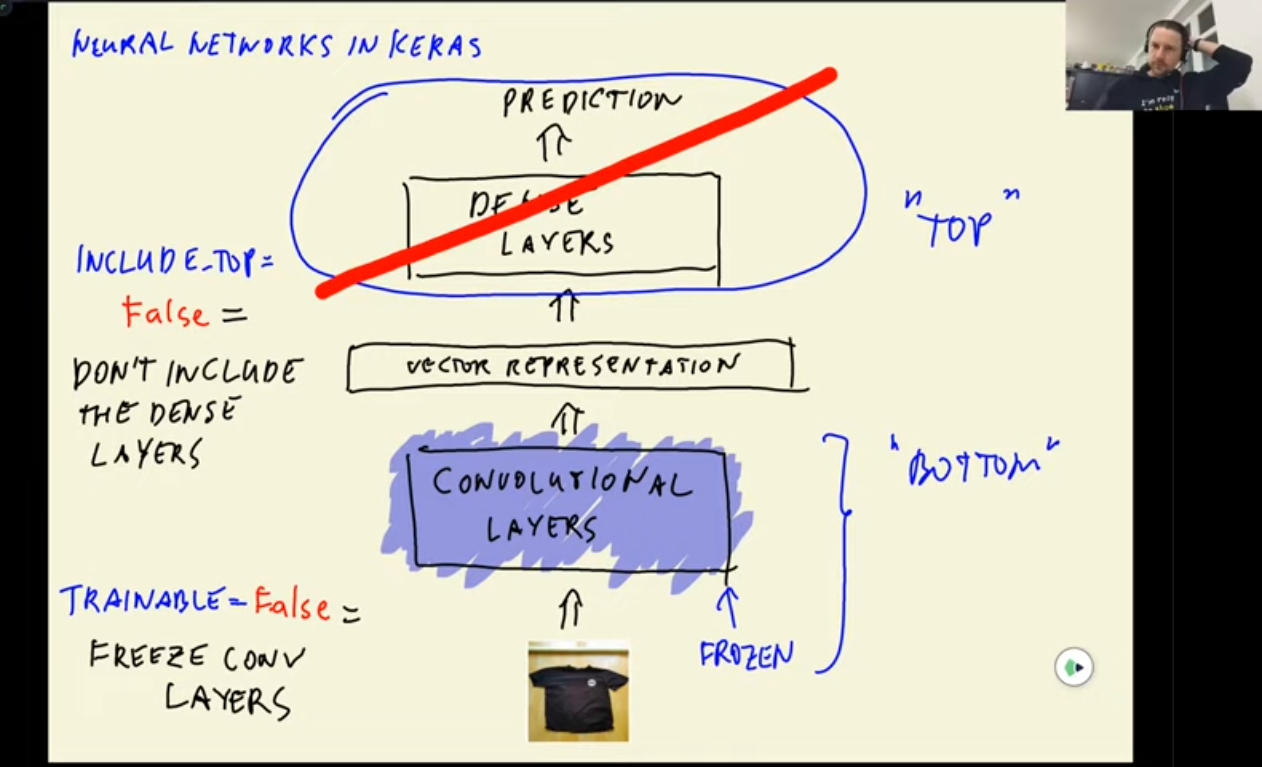

In [29]:
# # STEP 1 only
# # Creating new top
# inputs = keras.Input(shape=(150, 150, 3))

# # Apply base model to inputs and get something we will call Base
# base = base_model(inputs)

# # Wrap everything into Keras model
# outputs = base

# model = keras.Model(inputs, outputs)

In [30]:
# preds = model.predict(X)

In [31]:
# preds.shape

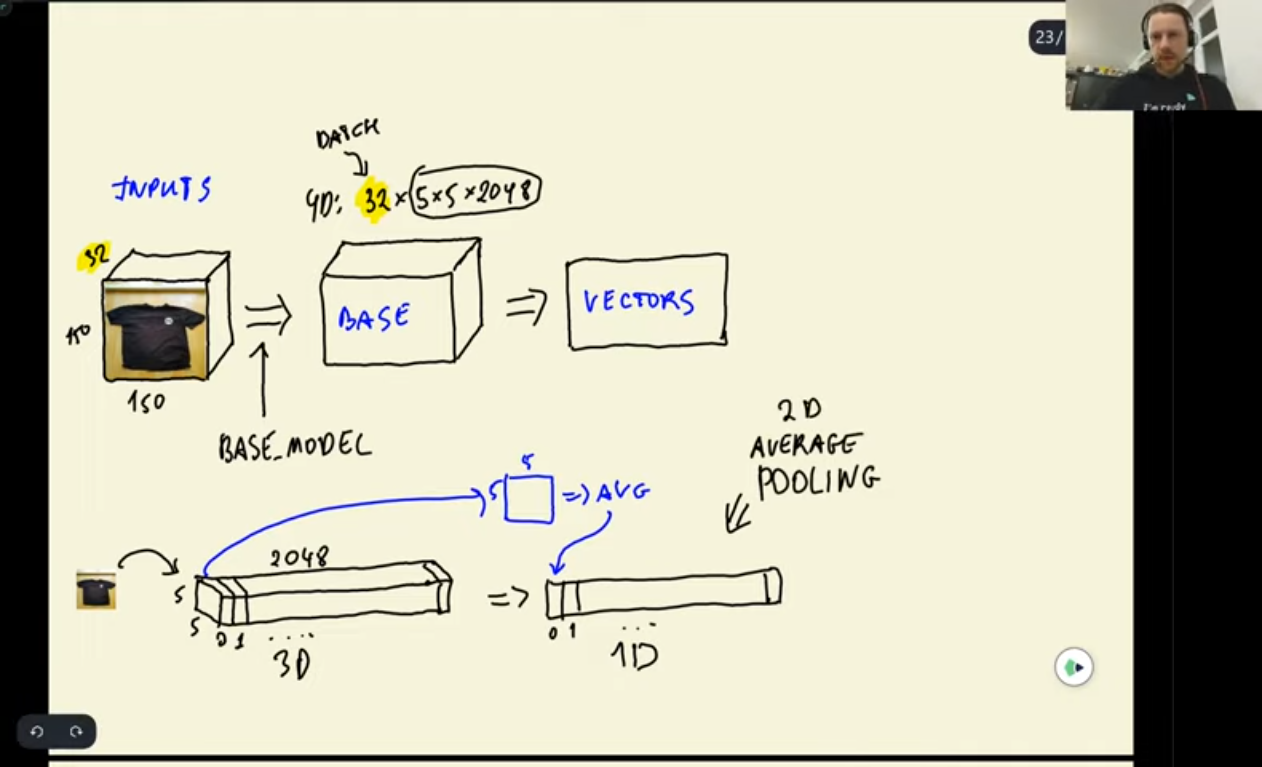

In [32]:
# # FIRST TWO STEPS ONLY
# # Creating new top
# inputs = keras.Input(shape=(150, 150, 3))

# # Apply base model to inputs and get something we will call Base
# base = base_model(inputs)

# # Using 2D pooling
# # pooling = keras.layers.GlobalAveragePooling2D()
# # vectors = pooling(base)

# # Or even better - using functional style
# vectors = keras.layers.GlobalAveragePooling2D()(base)

# # Wrap everything into Keras model
# outputs = vectors

# model = keras.Model(inputs, outputs)

# preds = model.predict(X)

# preds.shape

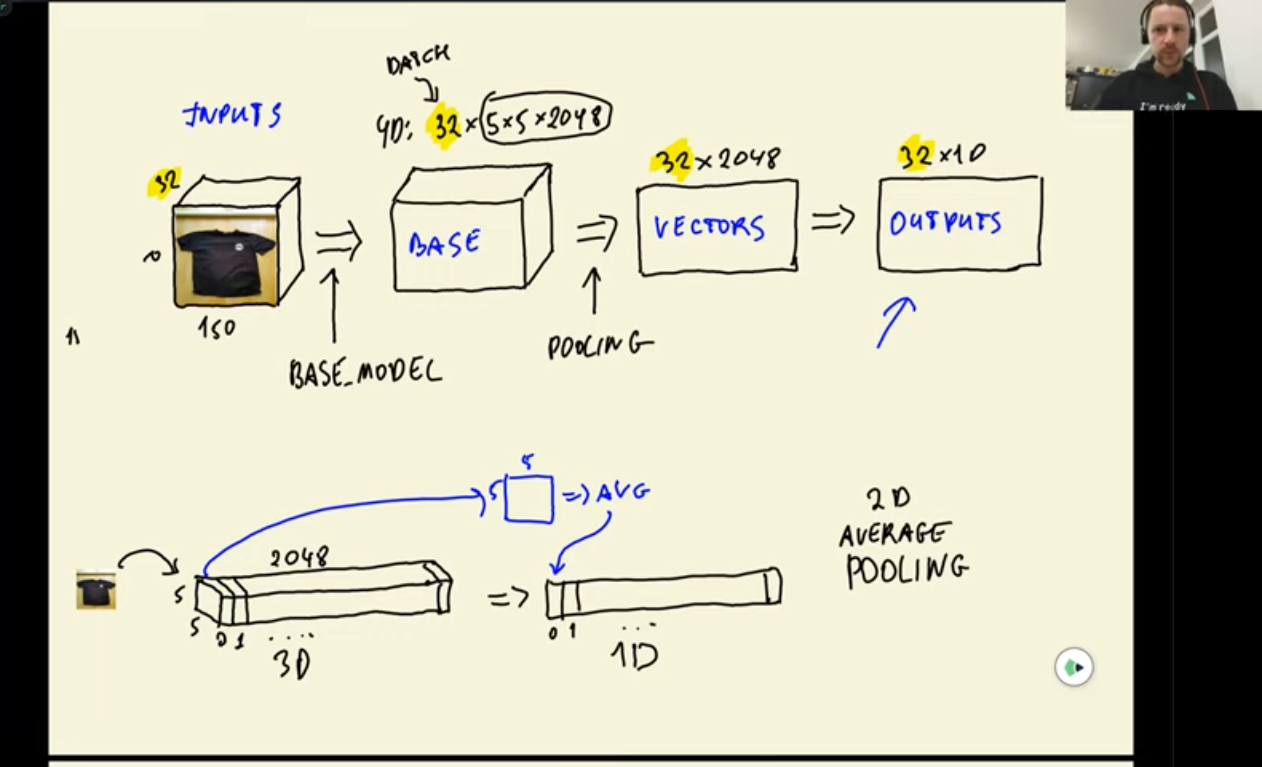

In [33]:
# FIRST TWO STEPS ONLY
# Creating new top
inputs = keras.Input(shape=(150, 150, 3))

# Apply base model to inputs and get something we will call Base
base = base_model(inputs, training=False)

# Or even better - using functional style
vectors = keras.layers.GlobalAveragePooling2D()(base)

# Wrap everything into Keras model
outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

preds = model.predict(X)

preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step


(32, 10)

#### This new model has the dense layer filled with random numbers. We need to train it

In [34]:
# Optimiser picks the best weights
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

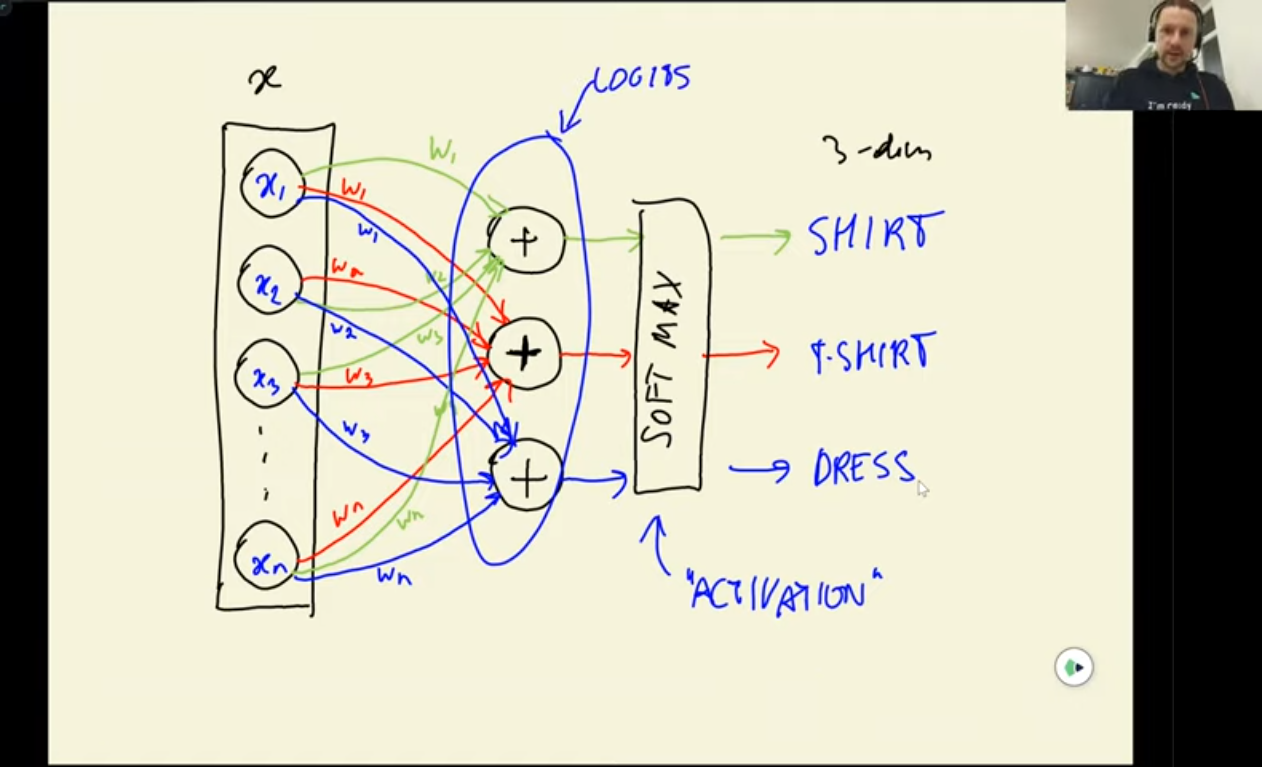

In [35]:
# Compile the model before training
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [36]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 45s 445ms/step - accuracy: 0.6754 - loss: 1.2309 - val_accuracy: 0.7478 - val_loss: 0.9467
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 426ms/step - accuracy: 0.8289 - loss: 0.5516 - val_accuracy: 0.7977 - val_loss: 0.7985
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 431ms/step - accuracy: 0.8745 - loss: 0.3802 - val_accuracy: 0.7977 - val_loss: 0.8554
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 425ms/step - accuracy: 0.9241 - loss: 0.2197 - val_accuracy: 0.7977 - val_loss: 0.9005
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 44s 456ms/step - accuracy: 0.9495 - loss: 0.1353 - val_accuracy: 0.7801 - val_loss: 0.8264
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 437ms/step - accuracy: 0.9664 - loss: 0.0936 - val_accuracy: 0.8211 - val_loss: 0.7924
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 434ms/step - accuracy: 0.9788 - loss: 0.0683 - val_accuracy: 0.7977 - val_loss: 0.9522
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 39s 408ms/step - accuracy: 0.9765 - loss: 0.0695 - val_accu

### 8.6 Adjusting the Learning Rate

What the learning rate is
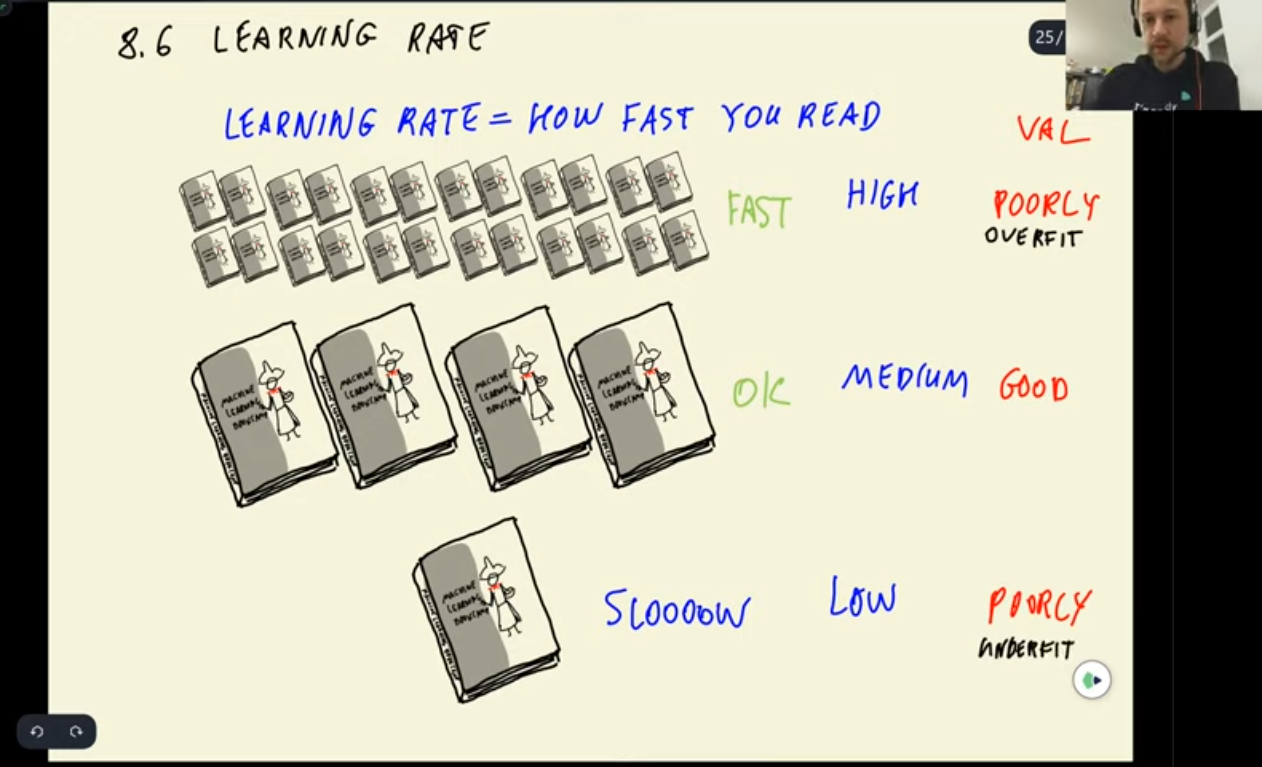

In [37]:
def make_model(learning_rate=0.01):
    base_model = Xception(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
    )

    base_model.trainable=False

    ###############################################################

    inputs = keras.Input(shape=(150, 150, 3))

    # Apply base model to inputs and get something we will call Base
    base = base_model(inputs, training=False)

    # Or even better - using functional style
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    # Wrap everything into Keras model
    outputs = keras.layers.Dense(10)(vectors)
    
    model = keras.Model(inputs, outputs)

    ###############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=['accuracy'])

    return model

In [38]:
# Training - itterate over different values of learning rate
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history
    
    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 44s 438ms/step - accuracy: 0.3214 - loss: 2.0122 - val_accuracy: 0.5103 - val_loss: 1.6735
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 428ms/step - accuracy: 0.5544 - loss: 1.4219 - val_accuracy: 0.5982 - val_loss: 1.3037
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 448ms/step - accuracy: 0.6398 - loss: 1.1666 - val_accuracy: 0.6716 - val_loss: 1.1162
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 384ms/step - accuracy: 0.6832 - loss: 1.0220 - val_accuracy: 0.7126 - val_loss: 1.0030
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 422ms/step - accuracy: 0.7089 - loss: 0.9264 - val_accuracy: 0.7273 - val_loss: 0.9202
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 417ms/step - accuracy: 0.7269 - loss: 0.8578 - val_accuracy: 0.7478 - val_loss: 0.8633
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 426ms/step - accuracy: 0.7477 - loss: 0.8041 - val_accuracy: 0.7595 - val_loss: 0.8196
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 423ms/step - accuracy: 0.7581 - loss: 0.7586 - v

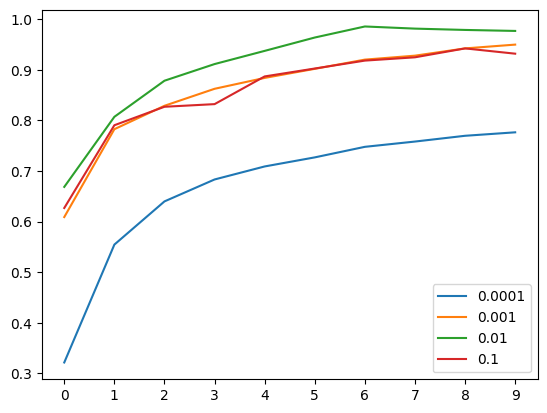

In [39]:
for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

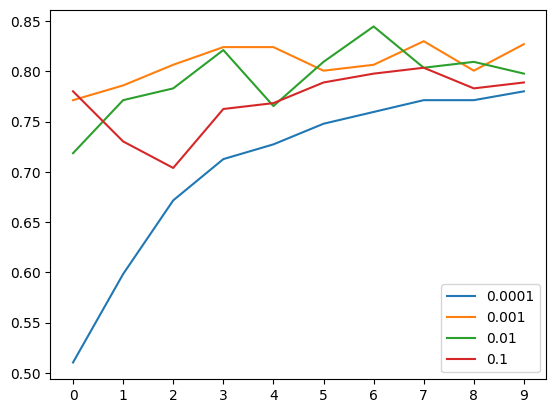

In [40]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

In [41]:
del scores[0.1]
del scores[0.0001]

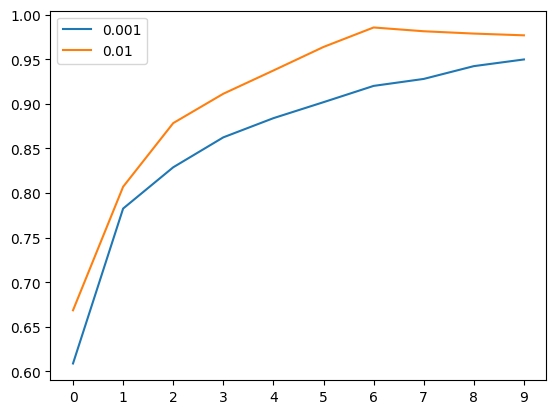

In [42]:
for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

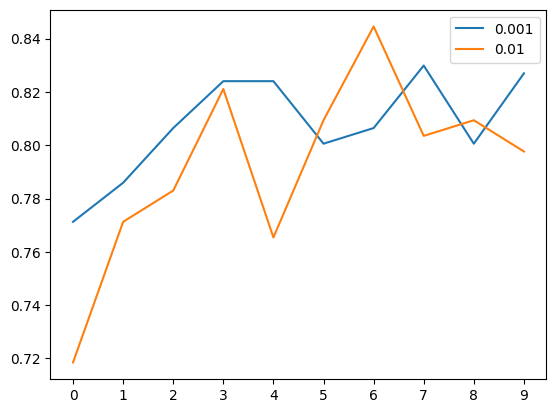

In [43]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

In [44]:
# Best learning rate is
learning_rate = 0.001

### 8.7 Checkpointing

Saving our model on certain conditions

In [47]:
# Callbacks to save the best model based on the maximum accuracy
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [48]:
learning_rate = 0.001

model = make_model(learning_rate=lr)

history = model.fit(
    train_ds, 
    epochs=10, 
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5882 - loss: 1.5558

96/96 ━━━━━━━━━━━━━━━━━━━━ 39s 386ms/step - accuracy: 0.6819 - loss: 1.1837 - val_accuracy: 0.7683 - val_loss: 0.9332
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.8338 - loss: 0.5232

96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 384ms/step - accuracy: 0.8331 - loss: 0.5392 - val_accuracy: 0.8094 - val_loss: 0.7071
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 385ms/step - accuracy: 0.8853 - loss: 0.3377 - val_accuracy: 0.8065 - val_loss: 0.8246
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 382ms/step - accuracy: 0.9117 - loss: 0.2607 - val_accuracy: 0.8035 - val_loss: 0.8473
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 384ms/step - accuracy: 0.9433 - loss: 0.1445 - val_accuracy: 0.7947 - val_loss: 0.8405
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9686 - loss: 0.0926

96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 386ms/step - accuracy: 0.9632 - loss: 0.1024 - val_accuracy: 0.8152 - val_loss: 0.9427
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 385ms/step - accuracy: 0.9769 - loss: 0.0733 - val_accuracy: 0.7977 - val_loss: 0.8725
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9793 - loss: 0.0764

96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 387ms/step - accuracy: 0.9749 - loss: 0.0869 - val_accuracy: 0.8387 - val_loss: 0.8860
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 38s 392ms/step - accuracy: 0.9831 - loss: 0.0605 - val_accuracy: 0.8006 - val_loss: 0.8952
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 386ms/step - accuracy: 0.9759 - loss: 0.0743 - val_accuracy: 0.8328 - val_loss: 0.9036


### 8.8 Adding more layers

In [49]:
# Adding layers

def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
    )

    base_model.trainable=False

    ###############################################################

    inputs = keras.Input(shape=(150, 150, 3))

    # Apply base model to inputs and get something we will call Base
    base = base_model(inputs, training=False)

    # Or even better - using functional style
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    # New layers
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    
    # Wrap everything into Keras model
    outputs = keras.layers.Dense(10)(inner)
    
    model = keras.Model(inputs, outputs)

    ###############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=['accuracy'])

    return model

In [50]:
# Training - itterate over different values of layer size
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history
    
    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 39s 387ms/step - accuracy: 0.4847 - loss: 1.5474 - val_accuracy: 0.6422 - val_loss: 1.1332
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 384ms/step - accuracy: 0.6884 - loss: 0.9602 - val_accuracy: 0.7302 - val_loss: 0.8602
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 382ms/step - accuracy: 0.7588 - loss: 0.7405 - val_accuracy: 0.7537 - val_loss: 0.7643
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 382ms/step - accuracy: 0.7986 - loss: 0.6169 - val_accuracy: 0.7419 - val_loss: 0.7168
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 381ms/step - accuracy: 0.8246 - loss: 0.5396 - val_accuracy: 0.7742 - val_loss: 0.6739
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 382ms/step - accuracy: 0.8494 - loss: 0.4702 - val_accuracy: 0.7625 - val_loss: 0.6852
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 383ms/step - accuracy: 0.8660 - loss: 0.4170 - val_accuracy: 0.7771 - val_loss: 0.6758
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 381ms/step - accuracy: 0.8875 - loss: 0.3734 - val_a

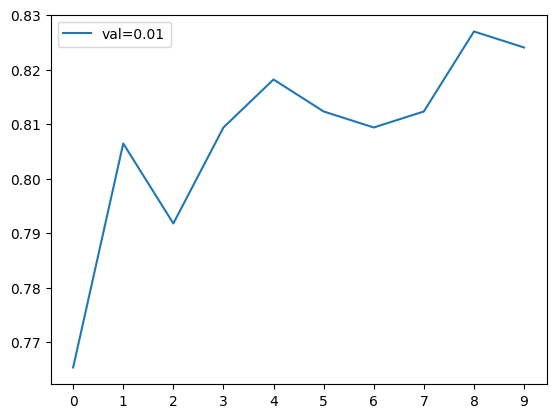

In [51]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.legend()

### 8.9 Regularization and dropout